<a href="https://colab.research.google.com/github/antonDinkov/AI_integrationsForDev/blob/main/IMAGEwithGEMINI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install -q google-genai

In [ ]:
from google import genai
from google.colab import userdata
from pprint import pprint
from IPython.display import Image, display, Markdown
import base64


api_key = userdata.get("Gemini_API_Key")
client = genai.Client(api_key=api_key)

In [ ]:
def print_response(response):
  print(f"Response is: {response.id}")
  print(f"Input tokens: {response.usage.total_input_tokens}; Output tokens: {response.usage.total_output_tokens}")

  if response.output_text:
        display(Markdown(f"### 💬 Text response\n{response.output_text}"))

  if response.output_image:
        image_bytes = base64.b64decode(response.output_image.data)
        display(Markdown("### 🖼 Image response"))
        display(Image(data=image_bytes, format="png"))

        with open("generated_image.png", "wb") as f:
          f.write(image_bytes)

        print("Saved as generated_image.png")

In [ ]:
generate_portrait_prompt = """
                           A photorealistic portrait of a software developer. He is 24-years-old, from Italy, and wears glasses.
                           The scene is illuminated by the sunlight streaming through the open window, creating a welcoming and calm atmosphere.
                           Through the window a beautiful garden can be seen with all kinds of fruit trees and vegetables.
                           The overall mood is serene and masterful. Vertical portrait orientation.
                           """

In [ ]:
interaction = client.interactions.create(
    model="gemini-3.1-flash-lite-image",
    input=generate_portrait_prompt,
)

Response is: v1_Chd6ajlUYXRDYUE4MjJxdHNQNDdqYWtBdxIXemo5VGF0Q2FBODIycXRzUDQ3amFrQXc
Input tokens: 87; Output tokens: 1614


### 🖼 Image response

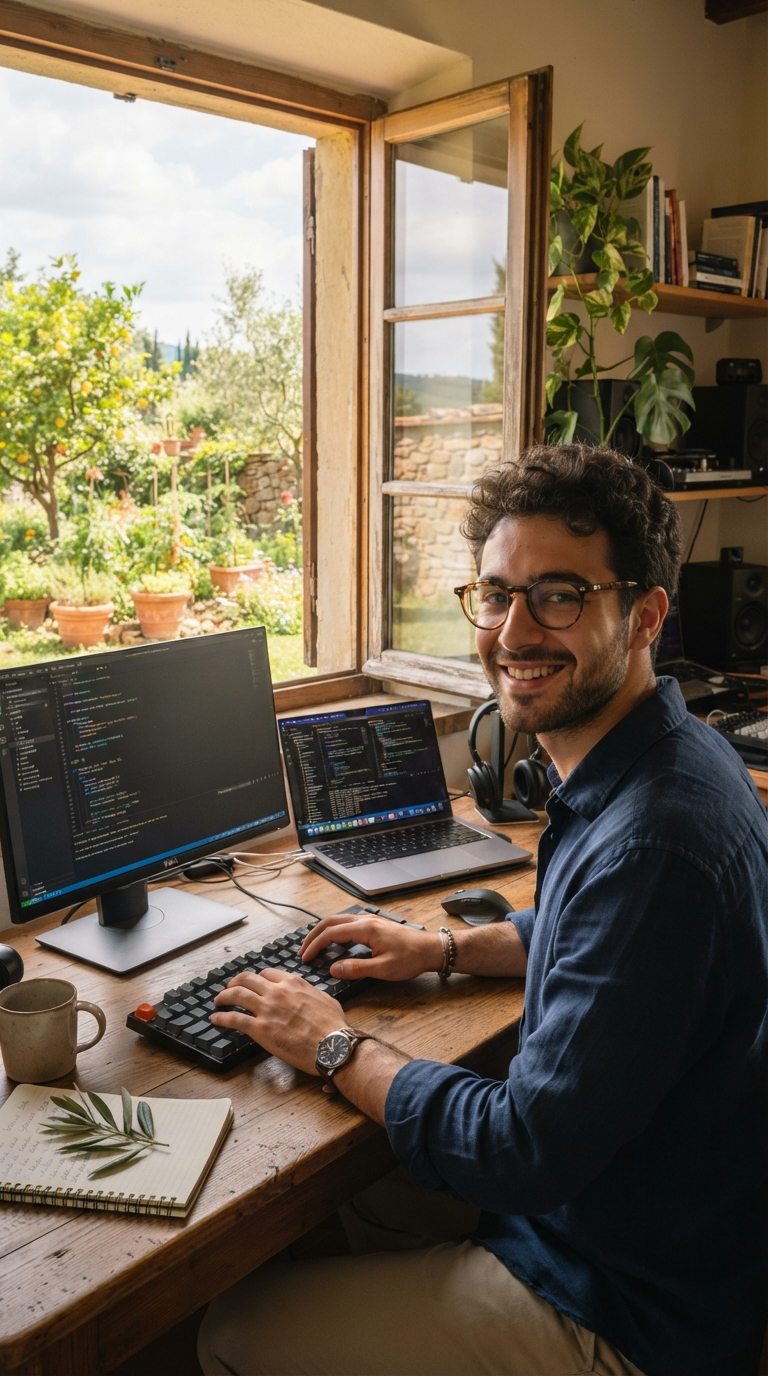

Saved as generated_image.png


In [ ]:
print_response(interaction)